Dataset Loaded: (20, 23)

High Demand + Low Consistency Vendors: 4

Critical Dependency Vendors: 3

Overdependent Vendors: 0

Top Risk Vendors:
                          vendor_name  combined_risk
11        phondaghat_pharmacy_&_honey       0.847917
12                  hopcoms_bengaluru       0.767251
5                  malnad_nutri_foods       0.699369
8                       tapcms_hassan       0.670446
15  kodagu_district_spice_cooperative       0.666637
17                  kolar_farmers_fpo       0.631757
9   sahaja_samrudha_organic_producers       0.627999
1             hubli_fresh_produce_co.       0.579519
6                        raichur_apmc       0.544244
10      shimoga_agri_tech_cooperative       0.534274


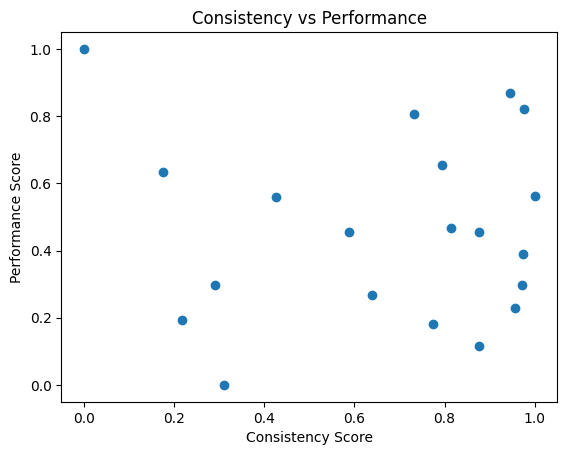

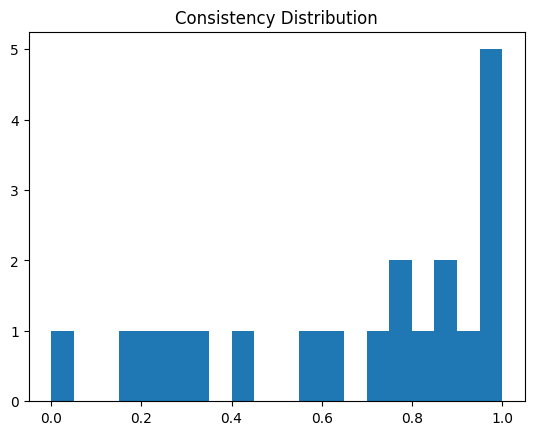

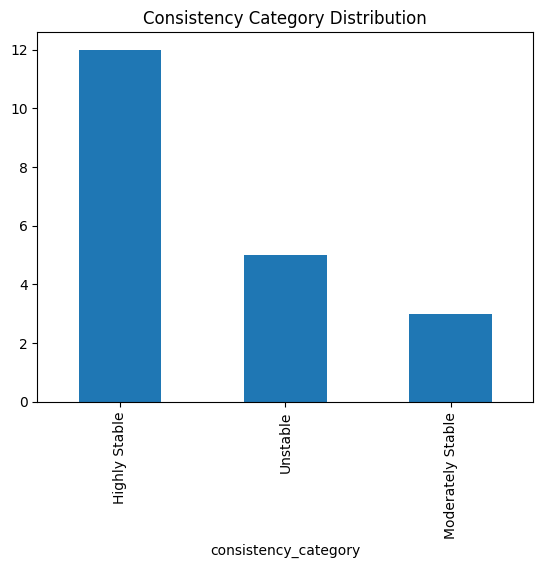


Day 25 Completed Successfully


In [1]:
# ==========================================================
# DAY 25 - SUPPLY CONSISTENCY & DEMAND IMBALANCE ANALYSIS
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

# ----------------------------------------------------------
# INPUT / OUTPUT PATHS
# ----------------------------------------------------------

INPUT_FILE = PROJECT_ROOT / "03_processed_data/day24_outputs/revenue_analysis_full.csv"
OUTPUT_FOLDER = PROJECT_ROOT / "03_processed_data/day25_outputs"

OUTPUT_FOLDER.mkdir(exist_ok=True)

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. SAFETY CHECKS (important columns)
# ----------------------------------------------------------

# Create demand if missing
if "demand" not in df.columns:
    df["demand"] = df["total_quantity"]

# Create performance_score if missing
if "performance_score" not in df.columns:
    df["performance_score"] = (
        (df["estimated_revenue"] - df["estimated_revenue"].min()) /
        (df["estimated_revenue"].max() - df["estimated_revenue"].min())
    )

# ----------------------------------------------------------
# 2. CONSISTENCY SCORE (proxy)
# ----------------------------------------------------------
# Using inverse variability assumption

mean_qty = df["total_quantity"].mean()

df["consistency_score"] = 1 / (1 + abs(df["total_quantity"] - mean_qty) / mean_qty)

# Normalize
df["consistency_score"] = (
    (df["consistency_score"] - df["consistency_score"].min()) /
    (df["consistency_score"].max() - df["consistency_score"].min())
)

# ----------------------------------------------------------
# 3. CONSISTENCY CATEGORY
# ----------------------------------------------------------

def consistency_category(score):
    if score >= 0.7:
        return "Highly Stable"
    elif score >= 0.4:
        return "Moderately Stable"
    else:
        return "Unstable"

df["consistency_category"] = df["consistency_score"].apply(consistency_category)

# ----------------------------------------------------------
# 4. DEMAND VS CONSISTENCY IMBALANCE
# ----------------------------------------------------------

df["imbalance_flag"] = (
    (df["demand"] > df["demand"].mean()) &
    (df["consistency_score"] < df["consistency_score"].mean())
)

imbalance_vendors = df[df["imbalance_flag"]]

imbalance_vendors.to_csv(
    OUTPUT_FOLDER / "high_demand_low_consistency.csv",
    index=False
)

print("\nHigh Demand + Low Consistency Vendors:", len(imbalance_vendors))

# ----------------------------------------------------------
# 5. CRITICAL DEPENDENCY (HIGH DEMAND + LOW PERFORMANCE)
# ----------------------------------------------------------

critical_dependency = df[
    (df["demand"] > df["demand"].mean()) &
    (df["performance_score"] < df["performance_score"].mean())
]

critical_dependency.to_csv(
    OUTPUT_FOLDER / "critical_dependency_vendors.csv",
    index=False
)

print("\nCritical Dependency Vendors:", len(critical_dependency))

# ----------------------------------------------------------
# 6. OVERDEPENDENCE DETECTION
# ----------------------------------------------------------

total_demand = df["demand"].sum()

df["demand_share"] = df["demand"] / total_demand

overdependent = df[df["demand_share"] > 0.1]

overdependent.to_csv(
    OUTPUT_FOLDER / "overdependent_vendors.csv",
    index=False
)

print("\nOverdependent Vendors:", len(overdependent))

# ----------------------------------------------------------
# 7. COMBINED RISK SCORE
# ----------------------------------------------------------

df["combined_risk"] = (
    df["risk_score"] * 0.4 +
    (1 - df["consistency_score"]) * 0.3 +
    (df["avg_defect"] / df["avg_defect"].max()) * 0.3
)

top_risk = df.sort_values("combined_risk", ascending=False).head(10)

top_risk.to_csv(
    OUTPUT_FOLDER / "top_combined_risk_vendors.csv",
    index=False
)

print("\nTop Risk Vendors:")
print(top_risk[["vendor_name", "combined_risk"]])

# ----------------------------------------------------------
# 8. VISUALS
# ----------------------------------------------------------

# Consistency vs Performance
plt.figure()
plt.scatter(df["consistency_score"], df["performance_score"])
plt.xlabel("Consistency Score")
plt.ylabel("Performance Score")
plt.title("Consistency vs Performance")
plt.savefig(PROJECT_ROOT / "04_visualizations/consistency_vs_performance.png")
plt.show()
plt.close()

# Consistency Distribution
plt.figure()
plt.hist(df["consistency_score"], bins=20)
plt.title("Consistency Distribution")
plt.savefig(PROJECT_ROOT / "04_visualizations/consistency_distribution.png")
plt.show()
plt.close()

# Category Distribution
plt.figure()
df["consistency_category"].value_counts().plot(kind="bar")
plt.title("Consistency Category Distribution")
plt.savefig(PROJECT_ROOT / "04_visualizations/consistency_category.png")
plt.show()
plt.close()

# ----------------------------------------------------------
# 9. KPI SUMMARY
# ----------------------------------------------------------

summary = {
    "Total Vendors": len(df),
    "Unstable Vendors": len(df[df["consistency_category"] == "Unstable"]),
    "Critical Dependency Vendors": len(critical_dependency),
    "Average Consistency": df["consistency_score"].mean()
}

pd.DataFrame([summary]).to_csv(
    OUTPUT_FOLDER / "consistency_kpi_summary.csv",
    index=False
)

# ----------------------------------------------------------
# 10. FINAL SAVE
# ----------------------------------------------------------

df.to_csv(
    OUTPUT_FOLDER / "consistency_analysis_full.csv",
    index=False
)

print("\nDay 25 Completed Successfully")